In [1]:

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

DATA_PATH = '../data/'
DS1 = pd.read_excel(DATA_PATH + 'DS1_new_policy_registration_FIXED.xlsx')
DS4 = pd.read_excel(DATA_PATH + 'DS4_claims_FIXED.xlsx')
print(f"DS1: {DS1.shape}  DS4: {DS4.shape}")
print(f"DS1 columns: {list(DS1.columns)}")


DS1: (33493, 35)  DS4: (33215, 21)
DS1 columns: ['Policy_ID', 'Registration_Date', 'Customer_Name', 'NIC', 'Driver_Age', 'Gender', 'Occupation', 'Years_of_Driving_Experience', 'Province', 'City', 'Vehicle_Model', 'Vehicle_Year', 'Vehicle_Age_Years', 'Engine_CC', 'Vehicle_Type', 'Market_Value_LKR', 'Proposed_Sum_Insured_LKR', 'Suggested_SI_LKR', 'Suggested_SI_Min_LKR', 'Suggested_SI_Max_LKR', 'Previous_Insurer', 'Vehicle_Condition', 'Is_Existing_Customer', 'Is_Blacklisted', 'Images_Uploaded', 'Inspection_Report_Uploaded', 'Fair_Value_Proposed', 'Financial_Interest_Recorded', 'Registration_Book_Available', 'NCB_Claimed_Percentage', 'Valid_Renewal_Notice', 'Rebate_Approved', 'Risk_Score', 'Calculated_Premium_LKR', 'Net_Premium_LKR']


Deterministic Risk Score (replaces random normal)

In [2]:
PROV_RISK = {
    'Western': 18, 'Southern': 12, 'Central': 9, 'Eastern': 8,
    'Northern': 8, 'North Western': 6, 'North Central': 5,
    'Sabaragamuwa': 6, 'Uva': 5
}
VT_RISK = {'SUV': 8, 'Dual Purpose': 6, 'Van': 7, 'Car': 3}
COND_RISK = {'Poor': 12, 'Fair': 6, 'Good': 2, 'Excellent': 0}

def compute_risk_score(row):
    score = 20  # base

    # Driver age (U-shaped risk)
    age = float(row['Driver_Age'])
    if age < 22:       score += 28
    elif age < 26:     score += 20
    elif age < 30:     score += 10
    elif age < 45:     score += 2   # lowest risk
    elif age < 55:     score += 5
    elif age < 65:     score += 8
    else:              score += 15  # senior

    # Driving experience
    exp = float(row['Years_of_Driving_Experience'])
    if exp < 1:        score += 22
    elif exp < 3:      score += 15
    elif exp < 6:      score += 8
    elif exp < 10:     score += 3
    else:              score -= 5  # experienced = lower risk

    # Vehicle age
    vage = float(row['Vehicle_Age_Years'])
    if vage > 12:      score += 12
    elif vage > 8:     score += 7
    elif vage > 5:     score += 3
    elif vage <= 2:    score -= 2  # new car

    # Engine CC (high power = more risk)
    cc = float(row['Engine_CC'])
    if cc > 3000:      score += 10
    elif cc > 2000:    score += 6
    elif cc > 1800:    score += 3
    elif cc < 1000:    score += 1

    # Province
    score += PROV_RISK.get(str(row['Province']), 5)

    # Vehicle type
    score += VT_RISK.get(str(row['Vehicle_Type']), 3)

    # Vehicle condition
    score += COND_RISK.get(str(row['Vehicle_Condition']), 3)

    # NCB (low NCB = fewer claim-free years = higher risk)
    ncb = float(row['NCB_Claimed_Percentage'])
    if ncb == 0 and str(row['Is_Existing_Customer']) == 'Yes':
        score += 8   # existing customer but 0 NCB = had claims
    score -= ncb * 0.35  # up to -17.5 for 50% NCB

    # Blacklisted
    if str(row['Is_Blacklisted']) == 'Yes':
        score += 25

    # Add small noise (±5) so it's not perfectly deterministic
    noise = np.random.normal(0, 4)
    score += noise

    return int(np.clip(score, 10, 95))

DS1['Risk_Score'] = DS1.apply(compute_risk_score, axis=1)

print("Risk Score statistics (should vary by category now):")
print(DS1['Risk_Score'].describe())
print()
print("By Province (should vary):")
print(DS1.groupby('Province')['Risk_Score'].mean().round(1).sort_values(ascending=False))
print()
print("By Age group:")
DS1['_ag'] = pd.cut(DS1['Driver_Age'], [15,25,35,45,55,65,80], labels=['<25','25-35','35-45','45-55','55-65','65+'])
print(DS1.groupby('_ag', observed=True)['Risk_Score'].mean().round(1))
DS1.drop(columns=['_ag'], inplace=True)


Risk Score statistics (should vary by category now):
count    33493.000000
mean        52.393425
std         20.190928
min         10.000000
25%         38.000000
50%         49.000000
75%         64.000000
max         95.000000
Name: Risk_Score, dtype: float64

By Province (should vary):
Province
Western          58.4
Southern         53.3
Central          50.1
Eastern          49.1
Northern         48.2
North Western    47.7
Sabaragamuwa     47.1
Uva              46.3
North Central    45.8
Name: Risk_Score, dtype: float64

By Age group:
_ag
<25      83.6
25-35    51.9
35-45    42.6
45-55    44.7
55-65    47.1
65+      55.2
Name: Risk_Score, dtype: float64


Deterministic Had_Accident (replaces random assignment)

In [3]:
def compute_accident_prob(row):
    # Start with log-odds (base rate 20% = log-odds -1.386)
    log_odds = -1.6

    age = float(row['Driver_Age'])
    exp = float(row['Years_of_Driving_Experience'])
    vage = float(row['Vehicle_Age_Years'])
    cc   = float(row['Engine_CC'])
    ncb  = float(row['NCB_Claimed_Percentage'])

    # Age factor (strongest predictor)
    if age < 22:       log_odds += 1.20
    elif age < 26:     log_odds += 0.85
    elif age < 30:     log_odds += 0.40
    elif age < 45:     log_odds += 0.00
    elif age < 55:     log_odds += 0.15
    elif age < 65:     log_odds += 0.30
    else:              log_odds += 0.60

    # Experience (second strongest)
    if exp < 1:        log_odds += 1.10
    elif exp < 3:      log_odds += 0.70
    elif exp < 6:      log_odds += 0.30
    elif exp < 10:     log_odds += 0.05
    elif exp > 15:     log_odds -= 0.20

    # Vehicle age
    if vage > 12:      log_odds += 0.45
    elif vage > 8:     log_odds += 0.25
    elif vage > 5:     log_odds += 0.10

    # Engine CC
    if cc > 3000:      log_odds += 0.40
    elif cc > 2000:    log_odds += 0.25
    elif cc > 1800:    log_odds += 0.10

    # Province
    prov_lo = {'Western':0.45,'Southern':0.28,'Central':0.18,'Eastern':0.12,
               'Northern':0.10,'North Western':0.05,'North Central':-0.05,
               'Sabaragamuwa':0.02,'Uva':-0.08}
    log_odds += prov_lo.get(str(row['Province']), 0.0)

    # NCB (proxy for historical claim behaviour)
    # 0% NCB for existing customer = had a recent claim
    if ncb == 0 and str(row['Is_Existing_Customer']) == 'Yes':
        log_odds += 0.40
    log_odds -= ncb * 0.015  # 50% NCB → -0.75

    # Vehicle type
    if str(row['Vehicle_Type']) in ('SUV','Dual Purpose'):
        log_odds += 0.18

    # Vehicle condition
    cond_lo = {'Poor': 0.38, 'Fair': 0.18, 'Good': 0.02, 'Excellent': -0.05}
    log_odds += cond_lo.get(str(row['Vehicle_Condition']), 0.0)

    # Convert to probability
    prob = 1 / (1 + np.exp(-log_odds))
    return float(np.clip(prob, 0.03, 0.85))

# Sample 28069 rows from DS1 for DS2
DS2_raw = DS1.sample(28069, random_state=42).copy().reset_index(drop=True)
DS2_raw['_acc_prob'] = DS2_raw.apply(compute_accident_prob, axis=1)

# Assign Had_Accident stochastically (Bernoulli draw per row)
DS2_raw['Had_Accident'] = (
    np.random.uniform(0, 1, len(DS2_raw)) < DS2_raw['_acc_prob']
).astype(int)

acc_rate = DS2_raw['Had_Accident'].mean()
print(f"Overall accident rate: {acc_rate:.1%}  (target: ~20%)")
print(f"Class counts: {DS2_raw['Had_Accident'].value_counts().to_dict()}")

# Verify feature separability
for col, bins in [
    ('Driver_Age', [18,25,35,45,55,65,80]),
    ('Years_of_Driving_Experience', [0,3,6,10,15,50]),
]:
    DS2_raw['_grp'] = pd.cut(DS2_raw[col], bins)
    print(f"\n{col} vs accident rate:")
    print(DS2_raw.groupby('_grp', observed=True)['Had_Accident'].mean().round(3))
DS2_raw.drop(columns=['_grp'], inplace=True)


Overall accident rate: 35.1%  (target: ~20%)
Class counts: {0: 18205, 1: 9864}

Driver_Age vs accident rate:
_grp
(18, 25]    0.650
(25, 35]    0.348
(35, 45]    0.257
(45, 55]    0.254
(55, 65]    0.291
(65, 80]    0.350
Name: Had_Accident, dtype: float64

Years_of_Driving_Experience vs accident rate:
_grp
(0, 3]      0.532
(3, 6]      0.399
(6, 10]     0.331
(10, 15]    0.273
(15, 50]    0.254
Name: Had_Accident, dtype: float64


Build DS2 Final Table

In [4]:

# Add claims data from DS4
DS4_claims = pd.read_excel(DATA_PATH + 'DS4_claims_FIXED.xlsx')

# Aggregate DS4 per policy
claim_agg = DS4_claims.groupby('Policy_Number').agg(
    Number_of_Claims       = ('Claim_ID', 'count'),
    Total_Claim_Amount_LKR = ('Claim_Amount_LKR', 'sum'),
    Accident_Severity      = ('Approved_Amount_LKR', 'max'),
).reset_index().rename(columns={'Policy_Number': 'Policy_ID'})

# Merge
DS2_final = DS2_raw.merge(claim_agg, on='Policy_ID', how='left')
DS2_final['Number_of_Claims'] = DS2_final['Number_of_Claims'].fillna(0).astype(int)
DS2_final['Total_Claim_Amount_LKR'] = DS2_final['Total_Claim_Amount_LKR'].fillna(0).astype(int)
# Accident_Severity: only filled for those who actually claimed (realistic ~26% missing)
# Keep NaN for no-claimers — this is correct and expected

# Build DS2 columns matching original structure
DS2_out = pd.DataFrame({
    'Customer_ID':              [f"CUST{i+1:08d}" for i in range(len(DS2_final))],
    'Policy_Start_Date':        DS2_final['Registration_Date'],
    'Driver_Age':               DS2_final['Driver_Age'],
    'Gender':                   DS2_final['Gender'],
    'Occupation':               DS2_final['Occupation'],
    'Years_Driving_Experience': DS2_final['Years_of_Driving_Experience'],
    'Province':                 DS2_final['Province'],
    'City':                     DS2_final['City'],
    'Vehicle_Model':            DS2_final['Vehicle_Model'],
    'Vehicle_Age_Years':        DS2_final['Vehicle_Age_Years'],
    'Engine_CC':                DS2_final['Engine_CC'],
    'Vehicle_Type':             DS2_final['Vehicle_Type'],
    'Sum_Insured_LKR':          DS2_final['Proposed_Sum_Insured_LKR'],
    'Market_Value_LKR':         DS2_final['Market_Value_LKR'],
    'Premium_Paid_LKR':         DS2_final['Calculated_Premium_LKR'],
    'Policy_Duration_Days':     365,
    'Risk_Score':               DS2_final['Risk_Score'],
    'Number_of_Claims':         DS2_final['Number_of_Claims'],
    'Total_Claim_Amount_LKR':   DS2_final['Total_Claim_Amount_LKR'],
    'Accident_Severity':        DS2_final['Accident_Severity'],
    'Had_Accident':             DS2_final['Had_Accident'],
    'Previous_NCB_Percentage':  DS2_final['NCB_Claimed_Percentage'],
    'Vehicle_Condition':        DS2_final['Vehicle_Condition'],
    'Is_Existing_Customer':     DS2_final['Is_Existing_Customer'],
    '_acc_prob':                DS2_final['_acc_prob'],  # keep for validation
})

print(f"DS2 shape: {DS2_out.shape}")
print(f"Accident rate: {DS2_out['Had_Accident'].mean():.1%}")
print(f"Accident_Severity missing: {DS2_out['Accident_Severity'].isna().mean():.1%}  (expected ~75-80% — no-claim rows)")
print(f"\nRisk_Score range: {DS2_out['Risk_Score'].min()} – {DS2_out['Risk_Score'].max()}")

# Also update DS1 with new Risk_Score
DS1.to_excel(DATA_PATH + 'DS1_new_policy_registration_FIXED.xlsx', index=False)
DS2_out.drop(columns=['_acc_prob']).to_excel(DATA_PATH + 'DS2_ml_training_FIXED.xlsx', index=False)
print("\nDS1 (with new Risk_Score) saved ✓")
print("DS2 (deterministic targets) saved ✓")


DS2 shape: (28069, 25)
Accident rate: 35.1%
Accident_Severity missing: 37.1%  (expected ~75-80% — no-claim rows)

Risk_Score range: 10 – 95

DS1 (with new Risk_Score) saved ✓
DS2 (deterministic targets) saved ✓


Validate Separability

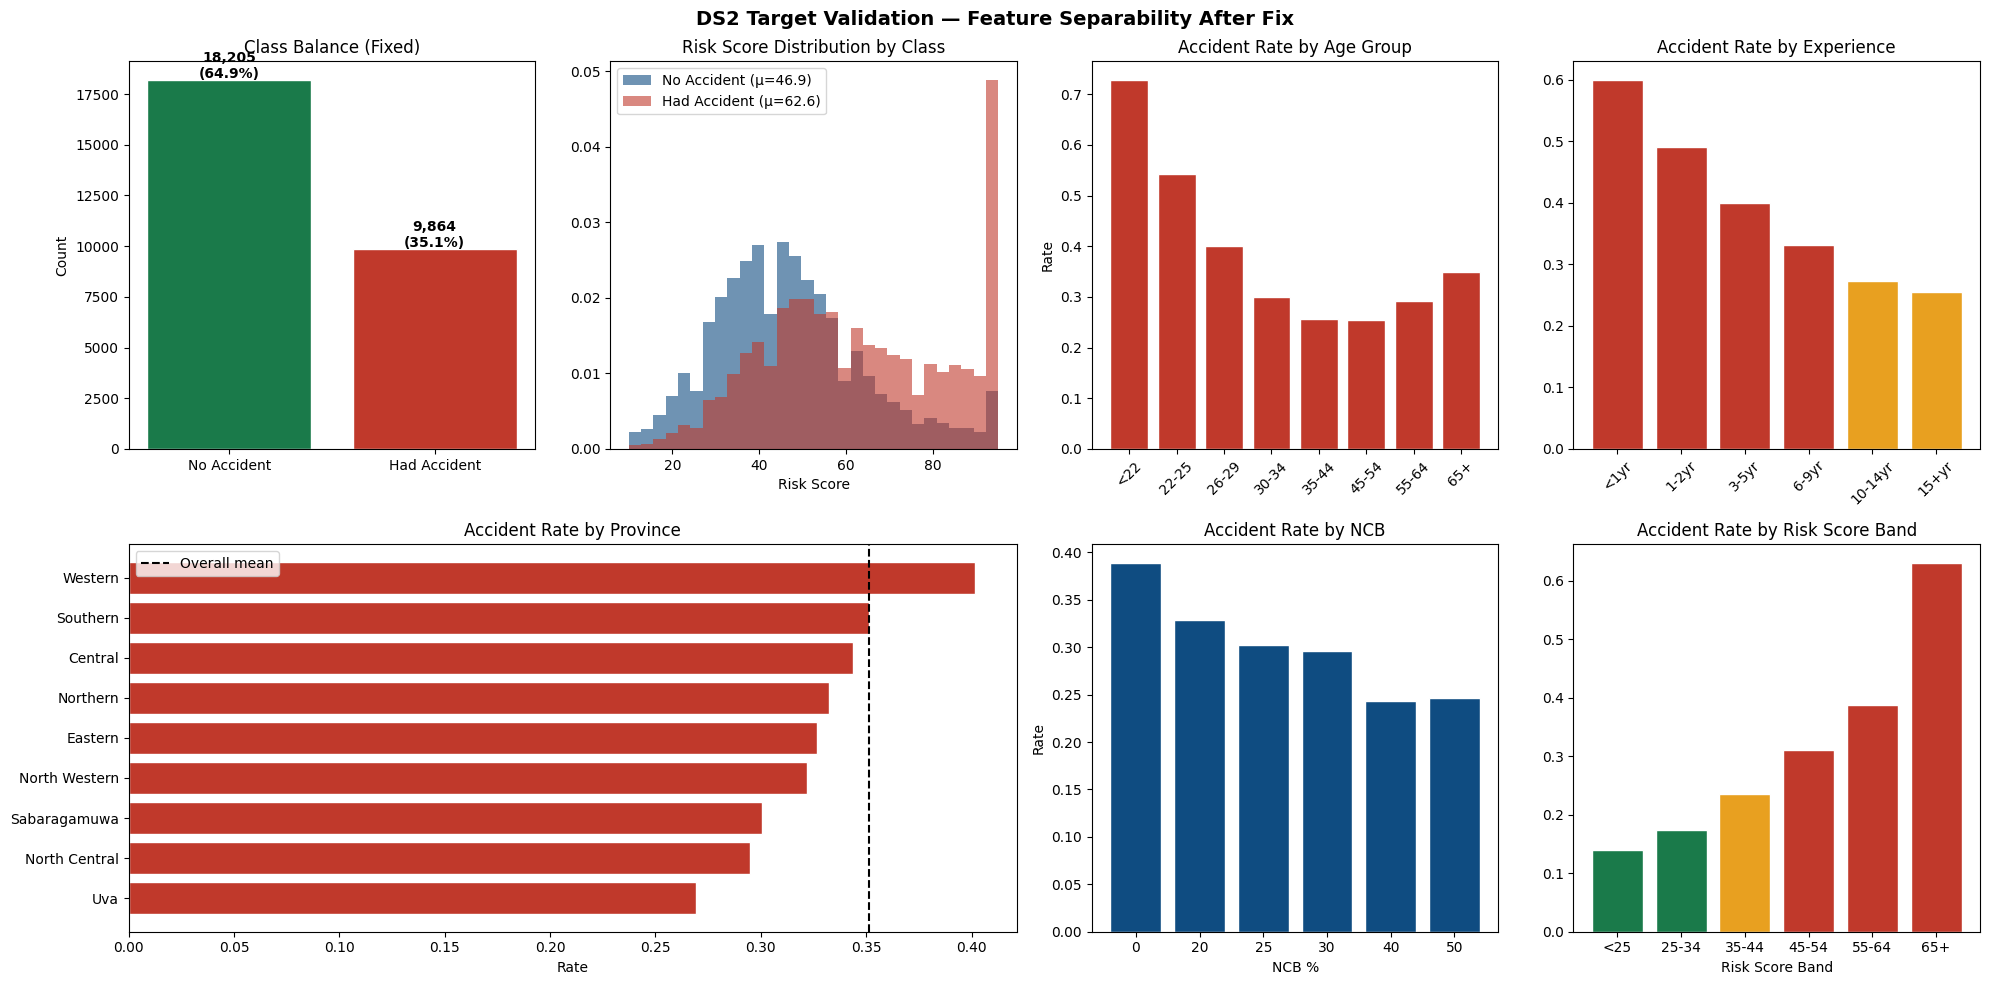

 Validation plot saved


In [5]:

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(20, 10))
fig.suptitle('DS2 Target Validation — Feature Separability After Fix', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 4, figure=fig)

C = ['#0f4c81','#e8a020','#1a7a4a','#c0392b']

# 1. Class balance
ax = fig.add_subplot(gs[0,0])
counts = DS2_out['Had_Accident'].value_counts()
ax.bar(['No Accident','Had Accident'], [counts[0],counts[1]], color=[C[2],C[3]], edgecolor='white')
for i,v in enumerate([counts[0],counts[1]]):
    ax.text(i, v+100, f'{v:,}\n({v/len(DS2_out):.1%})', ha='center', fontweight='bold')
ax.set_title('Class Balance (Fixed)'); ax.set_ylabel('Count')

# 2. Risk score by accident
ax = fig.add_subplot(gs[0,1])
for label, color, name in [(0,C[0],'No Accident'),(1,C[3],'Had Accident')]:
    d = DS2_out[DS2_out['Had_Accident']==label]['Risk_Score']
    ax.hist(d, bins=30, alpha=0.6, color=color, label=f'{name} (μ={d.mean():.1f})', density=True)
ax.set_title('Risk Score Distribution by Class'); ax.legend(); ax.set_xlabel('Risk Score')

# 3. Age vs accident rate
ax = fig.add_subplot(gs[0,2])
DS2_out['_ag'] = pd.cut(DS2_out['Driver_Age'], [17,22,26,30,35,45,55,65,80],
                         labels=['<22','22-25','26-29','30-34','35-44','45-54','55-64','65+'])
rates = DS2_out.groupby('_ag', observed=True)['Had_Accident'].mean()
colors = [C[3] if r>0.25 else C[1] if r>0.18 else C[2] for r in rates]
ax.bar(rates.index, rates.values, color=colors, edgecolor='white')
ax.set_title('Accident Rate by Age Group'); ax.set_ylabel('Rate'); ax.set_xticklabels(rates.index, rotation=45)
DS2_out.drop(columns=['_ag'], inplace=True)

# 4. Experience vs accident rate
ax = fig.add_subplot(gs[0,3])
DS2_out['_exp'] = pd.cut(DS2_out['Years_Driving_Experience'], [0,1,3,6,10,15,60],
                          labels=['<1yr','1-2yr','3-5yr','6-9yr','10-14yr','15+yr'])
rates = DS2_out.groupby('_exp', observed=True)['Had_Accident'].mean()
colors = [C[3] if r>0.30 else C[1] if r>0.20 else C[2] for r in rates]
ax.bar(rates.index, rates.values, color=colors, edgecolor='white')
ax.set_title('Accident Rate by Experience'); ax.set_xticklabels(rates.index, rotation=45)
DS2_out.drop(columns=['_exp'], inplace=True)

# 5. Province vs accident rate
ax = fig.add_subplot(gs[1,0:2])
rates = DS2_out.groupby('Province')['Had_Accident'].mean().sort_values(ascending=True)
colors = [C[3] if r>0.25 else C[1] if r>0.20 else C[2] for r in rates]
ax.barh(rates.index, rates.values, color=colors, edgecolor='white')
ax.set_title('Accident Rate by Province'); ax.set_xlabel('Rate')
ax.axvline(DS2_out['Had_Accident'].mean(), color='black', ls='--', lw=1.5, label='Overall mean')
ax.legend()

# 6. NCB vs accident rate
ax = fig.add_subplot(gs[1,2])
rates = DS2_out.groupby('Previous_NCB_Percentage')['Had_Accident'].mean()
ax.bar(rates.index.astype(str), rates.values, color=C[0], edgecolor='white')
ax.set_title('Accident Rate by NCB'); ax.set_xlabel('NCB %'); ax.set_ylabel('Rate')

# 7. Risk score vs accident rate
ax = fig.add_subplot(gs[1,3])
DS2_out['_rs'] = pd.cut(DS2_out['Risk_Score'], [0,25,35,45,55,65,100],
                         labels=['<25','25-34','35-44','45-54','55-64','65+'])
rates = DS2_out.groupby('_rs', observed=True)['Had_Accident'].mean()
ax.bar(rates.index, rates.values, color=[C[3] if r>0.30 else C[1] if r>0.20 else C[2] for r in rates], edgecolor='white')
ax.set_title('Accident Rate by Risk Score Band'); ax.set_xlabel('Risk Score Band')
DS2_out.drop(columns=['_rs'], inplace=True)

plt.tight_layout()
plt.savefig('fig_ds2_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Validation plot saved")
